In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [3]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/original_data/all_centroids_w31.csv"

# Caricamento dati
df = pd.read_csv(data_path)

# Prime righe
df.head()

,id,species,stage,site,cycle,sex,age,capture_reg,capture_subreg,lon,...,from_sea,type,type2,count_ind_sp,weight,wt_sp,wt_dur,wt_sp_sex,wt_ind,wt_ind_sp
0,100431_1,BLSC,W,W1,1,M,ASY,Southern New England,Rhode Island,-70.211090,...,NaN,0,0,89,0,3.120704,0.041096,5.909524,0.066667,0.000749
1,100431_1,BLSC,W,W2,1,M,ASY,Southern New England,Rhode Island,-73.892804,...,W,WD,W,89,1,3.120704,0.279338,5.909524,0.066667,0.000749
2,100431_1,BLSC,S,S1,1,M,ASY,Southern New England,Rhode Island,-62.408619,...,W,SM,SM,89,1,3.120704,0.095890,5.909524,0.066667,0.000749
3,100431_1,BLSC,M,M1,1,M,ASY,Southern New England,Rhode Island,-80.532833,...,S,SM,SM,89,1,3.120704,0.271233,5.909524,0.066667,0.000749
4,100431_1,BLSC,M,M2,1,M,ASY,Southern New England,Rhode Island,-79.399203,...,F,MD,WM,89,1,3.120704,0.076712,5.909524,0.066667,0.000749


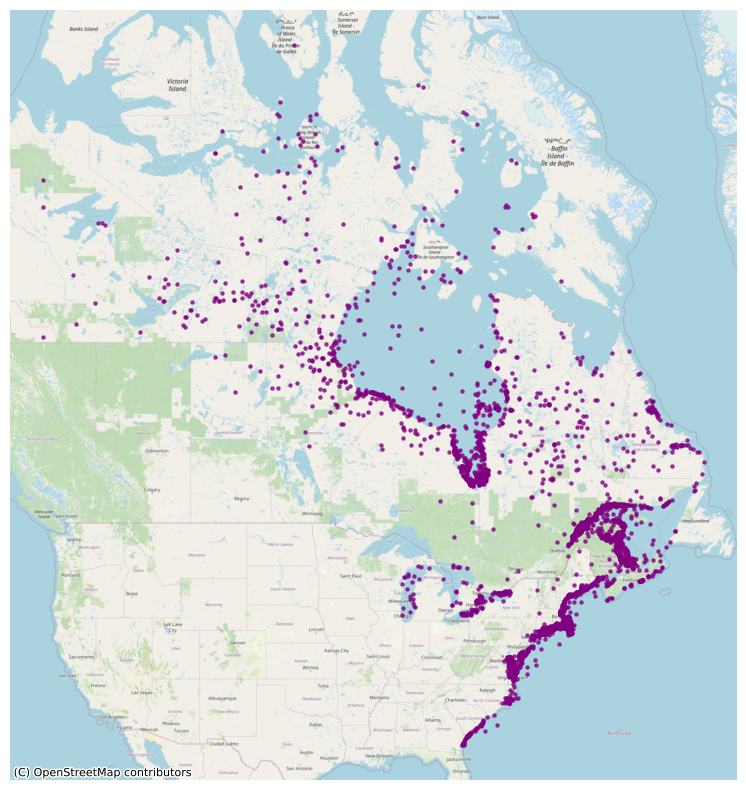

Numero di punti plottati: 3722


In [4]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"   # coordinate geografiche (lat/lon)
)

# Conversione in proiezione metrica (necessaria per contextily)
gdf_proj = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot dei punti
gdf_proj.plot(
    ax=ax,
    color="purple",
    markersize=5,  
    alpha=0.7,
    label="Centroidi" 
)

cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,  
    zoom=5 
)

ax.set_axis_off()
plt.show()

print(f"Numero di punti plottati: {len(gdf_proj)}")

Unique 'season' values: ['W' 'S' 'F' 'B']
Counts by season:
 season
W    1179
F    1106
S     975
B     462
Name: count, dtype: int64


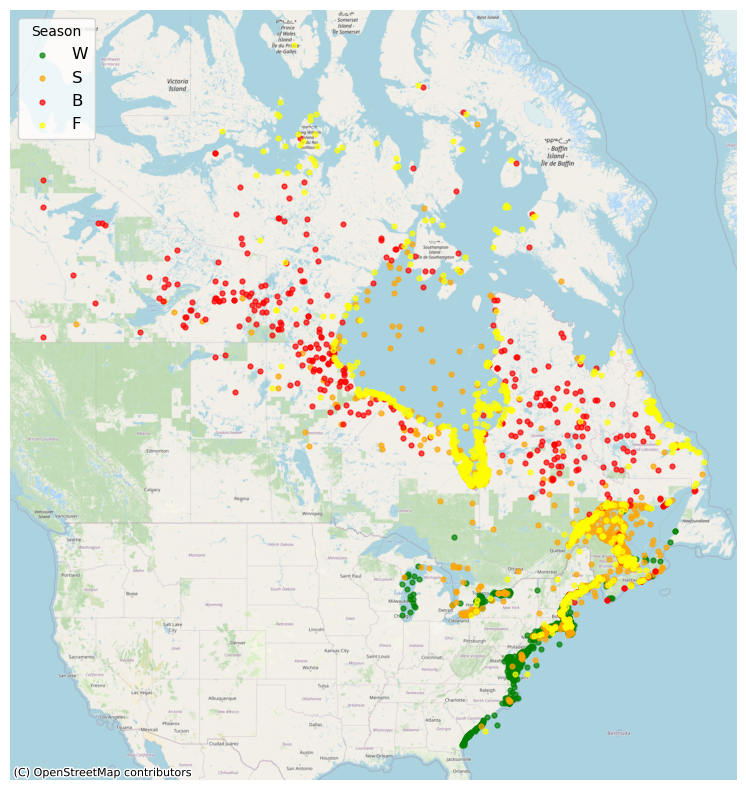

In [5]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

print("Unique 'season' values:", gdf['season'].unique())
print("Counts by season:\n", gdf['season'].value_counts())

season_color = {
    'W': 'green',  # winter
    'S': 'orange', # spring migration
    'B': 'red',    # breeding
    'F': 'yellow'  # fall migration
}

gdf_proj = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

for code, color in season_color.items():
    subset = gdf_proj[gdf_proj['season'] == code]
    if len(subset):
        subset.plot(ax=ax, color=color, markersize=12, alpha=0.7, label=code)

cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik, 
    zoom=5  
)

ax.set_axis_off() 
ax.legend(title='Season', fontsize=12, loc="upper left") 

plt.show()

   Kept 3246/3722 centroids
Point 0/3246
Point 100/3246
Point 200/3246
Point 300/3246
Point 400/3246
Point 500/3246
Point 600/3246
Point 700/3246
Point 800/3246
Point 900/3246
Point 1000/3246
Point 1100/3246
Point 1200/3246
Point 1300/3246
Point 1400/3246
Point 1500/3246
Point 1600/3246
Point 1700/3246
Point 1800/3246
Point 1900/3246
Point 2000/3246
Point 2100/3246
Point 2200/3246
Point 2300/3246
Point 2400/3246
Point 2500/3246
Point 2600/3246
Point 2700/3246
Point 2800/3246
Point 2900/3246
Point 3000/3246
Point 3100/3246
Point 3200/3246
   ✓ Clustering completed
   Testing k=20...
   Testing k=25...
   Testing k=30...
   Testing k=35...
   Testing k=40...
   Testing k=45...
   Testing k=50...
Optimal k (IMPROVEMENT-based) = 46
Optimal k (ABSOLUTE-based)    = 50

    NOTA: I due metodi suggeriscono k diversi!
      IMPROVEMENT dice k=46
      ABSOLUTE dice k=50

7. Generating visualizations...


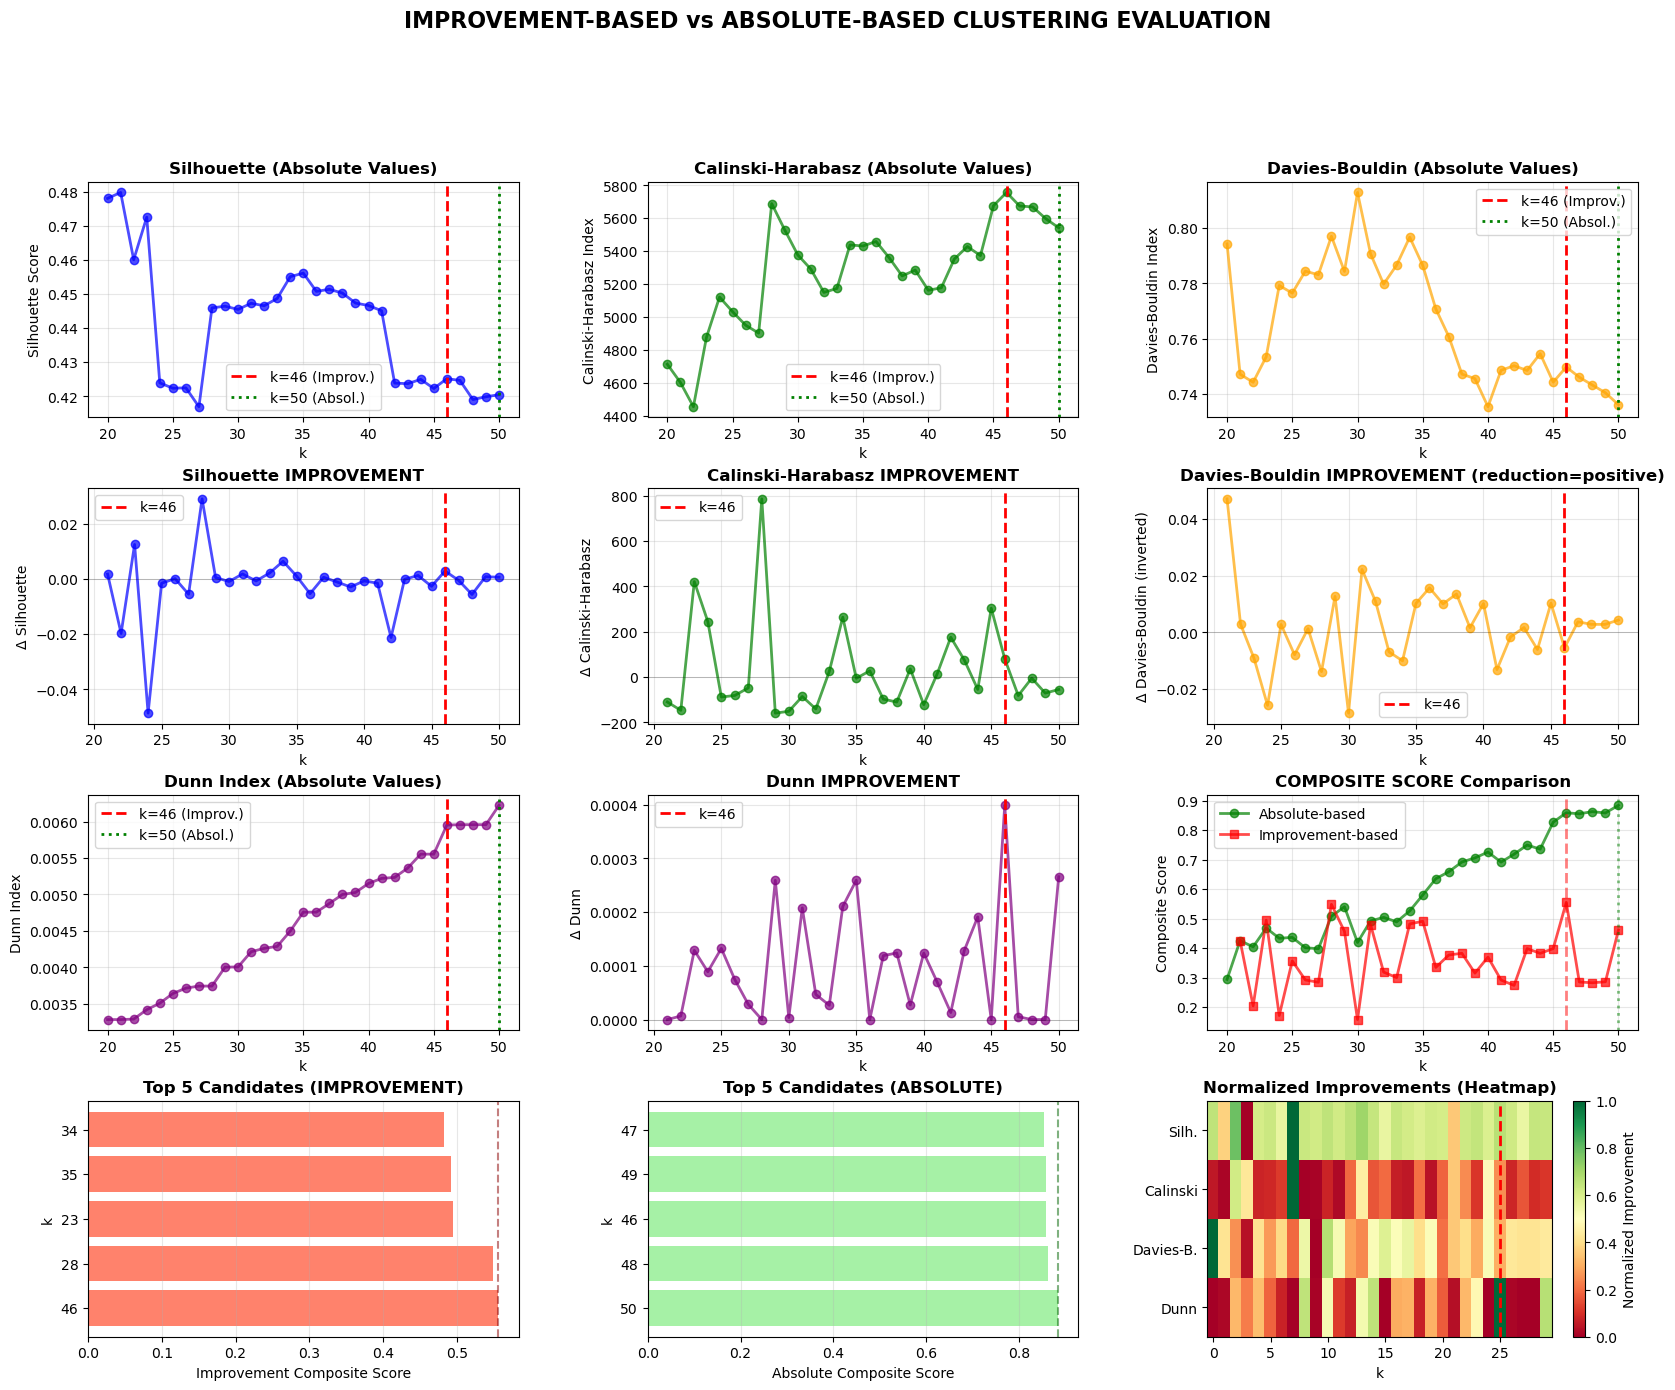

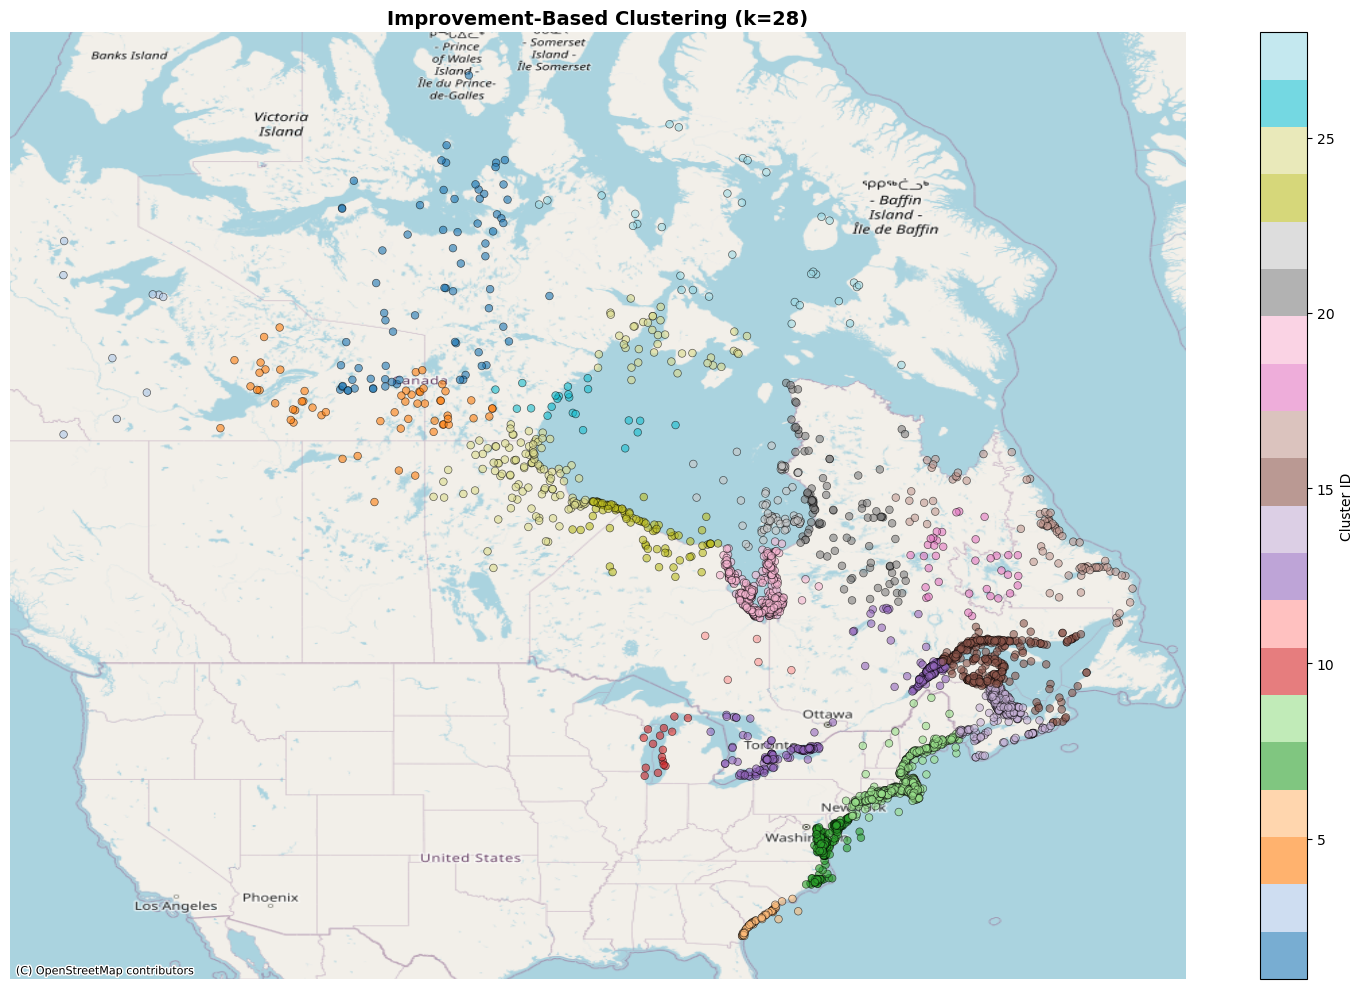

In [7]:
#Clustering pipeline
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pyproj
import contextily as cx

#Distanze geodetiche in km tra punti usando la formula di Haversine
def haversine_distance(coord1, coord2):

    lon1, lat1 = coord1
    lon2, lat2 = coord2
    
    #Conversione in radianti
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    #Raggio Terra in km
    return 6371 * c  

#Matrice di distanze geodetiche
def compute_geodesic_distance_matrix(coords):
  
    n = len(coords)
    distances = []
    
    for i in range(n):
        if i % 100 == 0:
            print(f"Point {i}/{n}")
        for j in range(i + 1, n):
            dist = haversine_distance(coords[i], coords[j])
            distances.append(dist)
    
    return np.array(distances)

# Proiezione coordinate geografiche (lon, lat) in metri (LAEA)
def project_coordinates(coords_lonlat, projection='laea'):
 
    lon = coords_lonlat[:, 0]
    lat = coords_lonlat[:, 1]
    
    lon_center = np.mean(lon)
    lat_center = np.mean(lat)
    
    if projection == 'laea':
        proj_string = f'+proj=laea +lat_0={lat_center} +lon_0={lon_center} +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs'
    else:
        raise ValueError(f"Unknown projection: {projection}")
    
    transformer = pyproj.Transformer.from_crs(
        "EPSG:4326",
        proj_string,
        always_xy=True
    )
    
    x, y = transformer.transform(lon, lat)
    return np.column_stack([x, y])


#Dunn Index
def dunn_index_projected(coords_lonlat, labels):

    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters < 2:
        return 0
    
    coords_projected = project_coordinates(coords_lonlat, projection='laea')
    dist_matrix = squareform(pdist(coords_projected, metric='euclidean'))
    
    #Min distanza inter-cluster
    min_inter = float('inf')
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            mask_i = labels == unique_labels[i]
            mask_j = labels == unique_labels[j]
            inter_dists = dist_matrix[np.ix_(mask_i, mask_j)]
            if inter_dists.size > 0:
                min_inter = min(min_inter, inter_dists.min())
    
    #Max diametro intra-cluster
    max_intra = 0
    for label in unique_labels:
        mask = labels == label
        if mask.sum() > 1:
            intra_dists = dist_matrix[np.ix_(mask, mask)]
            max_intra = max(max_intra, intra_dists.max())
    
    if max_intra == 0:
        return 0
    
    return min_inter / max_intra

#Valutazione clustering con più metriche
def evaluate_clustering_multimetric(coords_lonlat, labels):
    """
    Metriche di valutazione del clustering:
    - Silhouette: [-1, 1], higher = better
    - Calinski_Harabasz: [0, inf], higher = better
    - Davies_Bouldin: [0, inf], lower = better
    - Dunn: [0, inf], higher = better
    """
    #Coordinate proiettate per sklearn metrics (più accurate)
    coords_projected = project_coordinates(coords_lonlat, projection='laea')
    
    n_clusters = len(np.unique(labels))
    
    if n_clusters < 2:
        return {
            'silhouette': -1,
            'calinski_harabasz': 0,
            'davies_bouldin': float('inf'),
            'dunn': 0
        }
    
    try:
        silhouette = silhouette_score(coords_projected, labels)
    except:
        silhouette = -1
    
    try:
        calinski = calinski_harabasz_score(coords_projected, labels)
    except:
        calinski = 0
    
    try:
        davies_bouldin = davies_bouldin_score(coords_projected, labels)
    except:
        davies_bouldin = float('inf')
    
    try:
        dunn = dunn_index_projected(coords_lonlat, labels)
    except:
        dunn = 0
    
    return {
        'silhouette': silhouette,
        'calinski_harabasz': calinski,
        'davies_bouldin': davies_bouldin,
        'dunn': dunn
    }


#Calcolo improvement di ogni metrica rispetto al k precedente
def compute_improvements(df_results):
    """
    Per metriche "higher is better" (Silhouette, Calinski, Dunn):
        improvement = value[k] - value[k-1]
    
    Per metriche "lower is better" (Davies-Bouldin):
        improvement = value[k-1] - value[k]
    """
    df = df_results.copy()
    
    # Improvement per metriche "higher is better"
    df['silhouette_improvement'] = df['silhouette'].diff()
    df['calinski_improvement'] = df['calinski_harabasz'].diff()
    df['dunn_improvement'] = df['dunn'].diff()
    
    # Improvement per metrica "lower is better"
    df['davies_bouldin_improvement'] = -df['davies_bouldin'].diff()
    return df

#Normalizzazione degli improvement su scala [0, 1]
def normalize_improvements(df_results):
  
    df = df_results.copy()
    
    improvement_cols = [
        'silhouette_improvement',
        'calinski_improvement', 
        'davies_bouldin_improvement',
        'dunn_improvement'
    ]
    
    for col in improvement_cols:
        values = df[col].dropna()
        
        if len(values) == 0:
            df[f'{col}_norm'] = 0
            continue
        
        min_val = values.min()
        max_val = values.max()
        
        if max_val == min_val:
            df[f'{col}_norm'] = 0.5
        else:
            df[f'{col}_norm'] = (df[col] - min_val) / (max_val - min_val)
        
        df[f'{col}_norm'] = df[f'{col}_norm'].fillna(0)
    
    return df


def intelligent_clustering_pipeline(data, min_k=20, max_k=50,
                                     remove_first=True,
                                     individual_col='id',
                                     lon_col='lon', lat_col='lat'):
   
    #Rimozione del primo centroide per ogni individuo
    if remove_first and individual_col in data.columns:
        mask = data.groupby(individual_col).cumcount() > 0
        data_filtered = data[mask].copy()
        print(f"   Kept {len(data_filtered)}/{len(data)} centroids")
    else:
        data_filtered = data.copy()
    
    #Clustering con distanze geodetiche
    coords = np.column_stack([
        data_filtered[lon_col].values,
        data_filtered[lat_col].values
    ])
    
    dist_matrix = compute_geodesic_distance_matrix(coords)
    Z = linkage(dist_matrix, method='complete')
    print("   ✓ Clustering completed")
    
    results = []
    for k in range(min_k, max_k + 1):
        if k % 5 == 0:
            print(f"   Testing k={k}...")
        
        labels = fcluster(Z, k, criterion='maxclust')
        metrics = evaluate_clustering_multimetric(coords, labels)
        metrics['k'] = k
        results.append(metrics)
    
    df_results = pd.DataFrame(results)
    
    #Calcolo degli improvement
    df_results = compute_improvements(df_results)
    
    # Normalizzazione degli improvement
    df_results = normalize_improvements(df_results)
    
    df_results['improvement_composite_score'] = (
        df_results['silhouette_improvement_norm'] + 
        df_results['calinski_improvement_norm'] + 
        df_results['davies_bouldin_improvement_norm'] + 
        df_results['dunn_improvement_norm']
    ) / 4
    
    #Calcolo score assoluto per confronto
    df_results['silhouette_norm'] = (df_results['silhouette'] + 1) / 2
    
    ch_min = df_results['calinski_harabasz'].min()
    ch_max = df_results['calinski_harabasz'].max()
    df_results['calinski_norm'] = (df_results['calinski_harabasz'] - ch_min) / (ch_max - ch_min)
    
    db_min = df_results['davies_bouldin'].replace([np.inf, -np.inf], np.nan).min()
    db_max = df_results['davies_bouldin'].replace([np.inf, -np.inf], np.nan).max()
    df_results['davies_bouldin_norm'] = 1 - ((df_results['davies_bouldin'] - db_min) / (db_max - db_min))
    df_results['davies_bouldin_norm'] = df_results['davies_bouldin_norm'].fillna(0)
    
    dunn_min = df_results['dunn'].min()
    dunn_max = df_results['dunn'].max()
    df_results['dunn_norm'] = (df_results['dunn'] - dunn_min) / (dunn_max - dunn_min)
    
    df_results['absolute_composite_score'] = (
        df_results['silhouette_norm'] + 
        df_results['calinski_norm'] + 
        df_results['davies_bouldin_norm'] + 
        df_results['dunn_norm']
    ) / 4
    
    df_valid = df_results[df_results['k'] > min_k].copy()
    
    optimal_k_improvement = int(df_valid.loc[df_valid['improvement_composite_score'].idxmax(), 'k'])
    optimal_k_absolute = int(df_results.loc[df_results['absolute_composite_score'].idxmax(), 'k'])
    
    print(f"Optimal k (IMPROVEMENT-based) = {optimal_k_improvement}")
    print(f"Optimal k (ABSOLUTE-based)    = {optimal_k_absolute}")
    
    if optimal_k_improvement != optimal_k_absolute:
        print(f"\n    NOTA: I due metodi suggeriscono k diversi!")
        print(f"      IMPROVEMENT dice k={optimal_k_improvement}")
        print(f"      ABSOLUTE dice k={optimal_k_absolute}")
    
    # Improvement-based come default
    optimal_k = optimal_k_improvement

    final_labels = fcluster(Z, optimal_k, criterion='maxclust')
    data_filtered['cluster'] = final_labels
    
    print("\n7. Generating visualizations...")
    plot_improvement_results(df_results, optimal_k_improvement, optimal_k_absolute, min_k)
    

    
    return {
        'optimal_k_improvement': optimal_k_improvement,
        'optimal_k_absolute': optimal_k_absolute,
        'data_clustered': data_filtered,
        'linkage_matrix': Z,
        'results_df': df_results,
        'coords': coords
    }

#Confronto grafico tra improvement-based e absolute-based
def plot_improvement_results(df_results, optimal_k_improvement, optimal_k_absolute, min_k):    
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    #Silhouette (absolute)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df_results['k'], df_results['silhouette'], 'o-', linewidth=2, color='blue', alpha=0.7)
    ax1.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement} (Improv.)')
    ax1.axvline(optimal_k_absolute, color='green', linestyle=':', linewidth=2, label=f'k={optimal_k_absolute} (Absol.)')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title('Silhouette (Absolute Values)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    #Calinski-Harabasz (absolute)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(df_results['k'], df_results['calinski_harabasz'], 'o-', linewidth=2, color='green', alpha=0.7)
    ax2.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement} (Improv.)')
    ax2.axvline(optimal_k_absolute, color='green', linestyle=':', linewidth=2, label=f'k={optimal_k_absolute} (Absol.)')
    ax2.set_xlabel('k')
    ax2.set_ylabel('Calinski-Harabasz Index')
    ax2.set_title('Calinski-Harabasz (Absolute Values)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    #Davies-Bouldin (absolute)
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(df_results['k'], df_results['davies_bouldin'], 'o-', linewidth=2, color='orange', alpha=0.7)
    ax3.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement} (Improv.)')
    ax3.axvline(optimal_k_absolute, color='green', linestyle=':', linewidth=2, label=f'k={optimal_k_absolute} (Absol.)')
    ax3.set_xlabel('k')
    ax3.set_ylabel('Davies-Bouldin Index')
    ax3.set_title('Davies-Bouldin (Absolute Values)', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    #Silhouette improvement
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(df_results['k'], df_results['silhouette_improvement'], 'o-', linewidth=2, color='blue', alpha=0.7)
    ax4.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax4.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement}')
    ax4.set_xlabel('k')
    ax4.set_ylabel('Δ Silhouette')
    ax4.set_title('Silhouette IMPROVEMENT', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    #Calinski improvement
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(df_results['k'], df_results['calinski_improvement'], 'o-', linewidth=2, color='green', alpha=0.7)
    ax5.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax5.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement}')
    ax5.set_xlabel('k')
    ax5.set_ylabel('Δ Calinski-Harabasz')
    ax5.set_title('Calinski-Harabasz IMPROVEMENT', fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.legend()
    
    #Davies-Bouldin improvement
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.plot(df_results['k'], df_results['davies_bouldin_improvement'], 'o-', linewidth=2, color='orange', alpha=0.7)
    ax6.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax6.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement}')
    ax6.set_xlabel('k')
    ax6.set_ylabel('Δ Davies-Bouldin (inverted)')
    ax6.set_title('Davies-Bouldin IMPROVEMENT (reduction=positive)', fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.legend()
    
    #Dunn (absolute)
    ax7 = fig.add_subplot(gs[2, 0])
    ax7.plot(df_results['k'], df_results['dunn'], 'o-', linewidth=2, color='purple', alpha=0.7)
    ax7.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement} (Improv.)')
    ax7.axvline(optimal_k_absolute, color='green', linestyle=':', linewidth=2, label=f'k={optimal_k_absolute} (Absol.)')
    ax7.set_xlabel('k')
    ax7.set_ylabel('Dunn Index')
    ax7.set_title('Dunn Index (Absolute Values)', fontweight='bold')
    ax7.grid(True, alpha=0.3)
    ax7.legend()
    
    #Dunn improvement
    ax8 = fig.add_subplot(gs[2, 1])
    ax8.plot(df_results['k'], df_results['dunn_improvement'], 'o-', linewidth=2, color='purple', alpha=0.7)
    ax8.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax8.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, label=f'k={optimal_k_improvement}')
    ax8.set_xlabel('k')
    ax8.set_ylabel('Δ Dunn')
    ax8.set_title('Dunn IMPROVEMENT', fontweight='bold')
    ax8.grid(True, alpha=0.3)
    ax8.legend()
    
    #Confronto composite scores
    ax9 = fig.add_subplot(gs[2, 2])
    
    df_valid = df_results[df_results['k'] > min_k].copy()
    
    ax9.plot(df_results['k'], df_results['absolute_composite_score'], 
             'o-', linewidth=2, color='green', alpha=0.7, label='Absolute-based', markersize=6)
    ax9.plot(df_valid['k'], df_valid['improvement_composite_score'], 
             's-', linewidth=2, color='red', alpha=0.7, label='Improvement-based', markersize=6)
    ax9.axvline(optimal_k_improvement, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax9.axvline(optimal_k_absolute, color='green', linestyle=':', linewidth=2, alpha=0.5)
    ax9.set_xlabel('k')
    ax9.set_ylabel('Composite Score')
    ax9.set_title('COMPOSITE SCORE Comparison', fontweight='bold')
    ax9.grid(True, alpha=0.3)
    ax9.legend()
    
    #Top 5 candidati improvement-based
    ax10 = fig.add_subplot(gs[3, 0])
    top5_improv = df_valid.nlargest(5, 'improvement_composite_score')
    ax10.barh(top5_improv['k'].astype(str), top5_improv['improvement_composite_score'], color='tomato', alpha=0.8)
    ax10.axvline(x=top5_improv['improvement_composite_score'].iloc[0], color='darkred', linestyle='--', alpha=0.5)
    ax10.set_xlabel('Improvement Composite Score')
    ax10.set_ylabel('k')
    ax10.set_title('Top 5 Candidates (IMPROVEMENT)', fontweight='bold')
    ax10.grid(True, alpha=0.3, axis='x')
    
    #Top 5 candidati absolute-based
    ax11 = fig.add_subplot(gs[3, 1])
    top5_abs = df_results.nlargest(5, 'absolute_composite_score')
    ax11.barh(top5_abs['k'].astype(str), top5_abs['absolute_composite_score'], color='lightgreen', alpha=0.8)
    ax11.axvline(x=top5_abs['absolute_composite_score'].iloc[0], color='darkgreen', linestyle='--', alpha=0.5)
    ax11.set_xlabel('Absolute Composite Score')
    ax11.set_ylabel('k')
    ax11.set_title('Top 5 Candidates (ABSOLUTE)', fontweight='bold')
    ax11.grid(True, alpha=0.3, axis='x')
    
    ax12 = fig.add_subplot(gs[3, 2])
    improvement_cols = ['silhouette_improvement_norm', 'calinski_improvement_norm', 
                       'davies_bouldin_improvement_norm', 'dunn_improvement_norm']
    
    df_plot = df_valid[['k'] + improvement_cols].set_index('k')
    
    im = ax12.imshow(df_plot.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax12.set_yticks(range(len(improvement_cols)))
    ax12.set_yticklabels(['Silh.', 'Calinski', 'Davies-B.', 'Dunn'])
    ax12.set_xlabel('k')
    ax12.set_title('Normalized Improvements (Heatmap)', fontweight='bold')
    
    optimal_idx = np.where(df_plot.index == optimal_k_improvement)[0]
    if len(optimal_idx) > 0:
        ax12.axvline(optimal_idx[0], color='red', linestyle='--', linewidth=2)
    
    plt.colorbar(im, ax=ax12, label='Normalized Improvement')
    
    fig.suptitle('IMPROVEMENT-BASED vs ABSOLUTE-BASED CLUSTERING EVALUATION', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()


def plot_clusters_on_map(data_clustered, optimal_k):
    
    fig, ax = plt.subplots(figsize=(15, 10))
    
    gdf_clustered = gpd.GeoDataFrame(
        data_clustered,
        geometry=gpd.points_from_xy(data_clustered['lon'], data_clustered['lat']),
        crs="EPSG:4326"
    )
    gdf_proj = gdf_clustered.to_crs(epsg=3857)
    
    scatter = ax.scatter(
        gdf_proj.geometry.x,
        gdf_proj.geometry.y,
        c=data_clustered['cluster'],
        cmap='tab20',
        s=30,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
    
    plt.colorbar(scatter, label='Cluster ID', ax=ax)
    ax.set_title(f'Improvement-Based Clustering (k={optimal_k})', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


#Esecuzione del pipeline di clustering
if __name__ == "__main__":

    data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/original_data/all_centroids_w31.csv"
    df = pd.read_csv(data_path)
    
    results = intelligent_clustering_pipeline(
        df,
        min_k=20,
        max_k=50,
        remove_first=True,
        individual_col='id',
        lon_col='lon',
        lat_col='lat'
    )
    
optimal_k = results['optimal_k_improvement']
data_clustered = results['data_clustered']

#Clustering con k=28 invece di k=46
from scipy.cluster.hierarchy import fcluster
labels_k28 = fcluster(results['linkage_matrix'], 28, criterion='maxclust')
data_clustered['cluster'] = labels_k28

#Plot mappa con k=28
plot_clusters_on_map(data_clustered, 28)

output_path = "centroids_clustered_k28.csv"
data_clustered.to_csv(output_path, index=False)

results_path = "clustering_metrics_comparison.csv"
results['results_df'].to_csv(results_path, index=False)

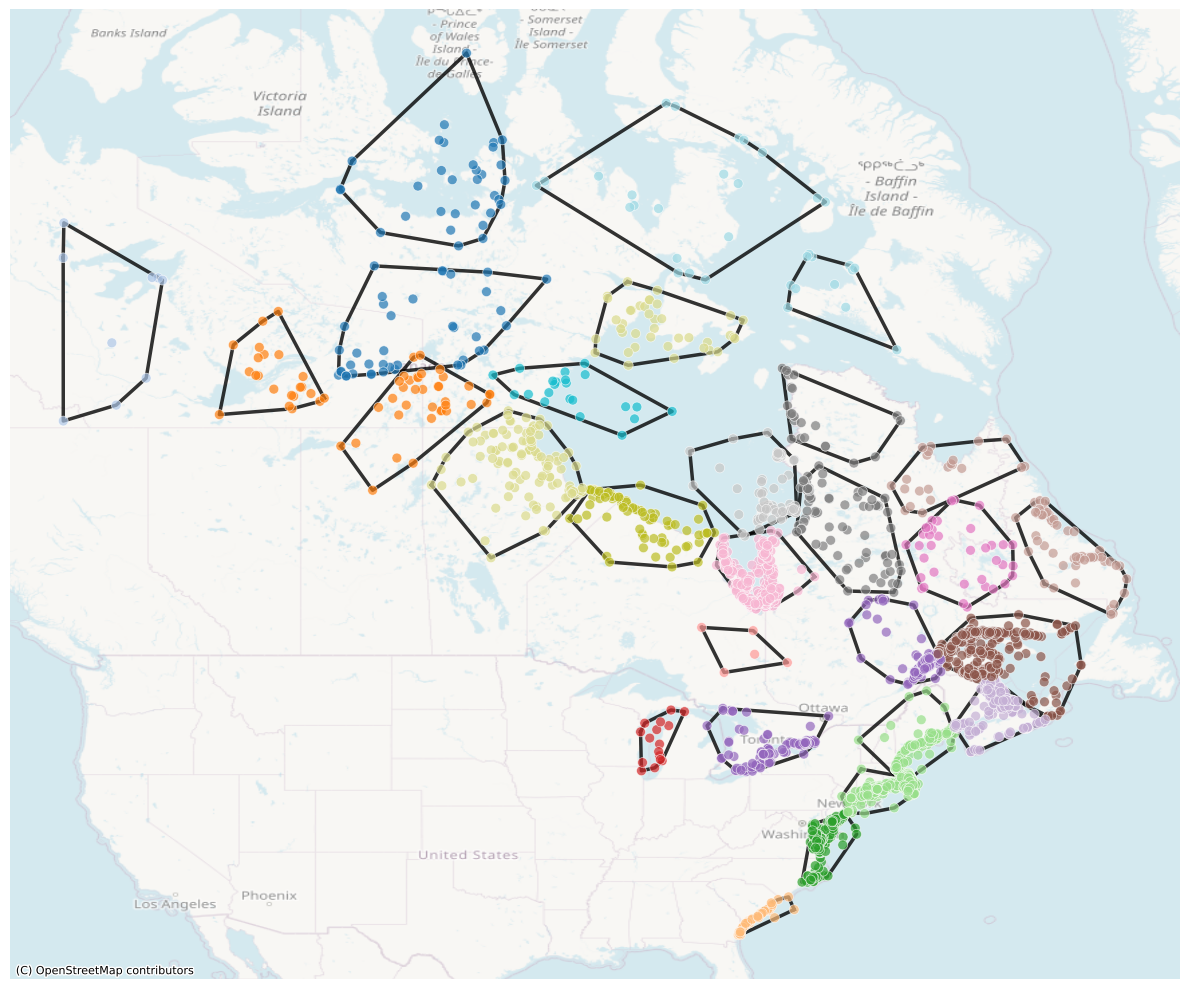

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
from scipy.cluster.hierarchy import fcluster
from shapely.ops import unary_union
from scipy.spatial import ConvexHull

labels_k28 = fcluster(results['linkage_matrix'], 28, criterion='maxclust')
data_k28 = results['data_clustered'].copy()
data_k28['cluster'] = labels_k28

gdf = gpd.GeoDataFrame(
    data_k28,
    geometry=gpd.points_from_xy(data_k28['lon'], data_k28['lat']),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12,10))

scatter = ax.scatter(
    gdf.geometry.x, 
    gdf.geometry.y, 
    c=labels_k28, 
    cmap='tab20',
    s=50, 
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5,
    zorder=3
)

for cluster_id in range(1, 29):
    cluster_points = gdf[gdf['cluster'] == cluster_id]
    
    if len(cluster_points) >= 3: 
        coords = np.column_stack([cluster_points.geometry.x, cluster_points.geometry.y])
        
        try:
            hull = ConvexHull(coords)
            hull_points = coords[hull.vertices]
            
            hull_points = np.vstack([hull_points, hull_points[0]])
        
            ax.plot(hull_points[:, 0], hull_points[:, 1], 
                   'k-', linewidth=2.5, alpha=0.8, zorder=2)
        except:
            pass 

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)

ax.axis('off')

plt.tight_layout()

plt.show()